# Lab 1 - Teleportation

* Protocol where a sender (Alice) transmits a qubit to a receiver (Bob) by making use of a shared entangled quantum state (one e-bit, to be specific) along with two bits of classical communication.
* The name *teleportation* is meant to be suggestive of the concept in science fiction where matter is transported from one location to another by a futuristic process, but it must be understood that matter is not teleported in quantum teleportation — what is actually teleported is quantum information.

## Setup

*  Alice and Bob share an e-bit: Alice holds a qubit $\mathsf{A}$, Bob holds a qubit $\mathsf{B}$, and together the pair $(\mathsf{A},\mathsf{B})$ is in the state $\vert\phi^+\rangle.$
* Alice then comes into possession of a third qubit $\mathsf{Q}$ that she wishes to transmit to Bob.
    * To say that Alice wishes to transmit the qubit $\mathsf{Q}$ to Bob means that Alice would like Bob to be holding a qubit that is in the same state that $\mathsf{Q}$ was in at the start of the protocol, having whatever correlations that $\mathsf{Q}$ had with other systems, as if Alice had physically handed $\mathsf{Q}$ to Bob.
* The state of the qubit $\mathsf{Q}$ is considered to be *unknown* to Alice and Bob, and no assumptions are made about it.
    * For example, the qubit $\mathsf{Q}$ might be entangled with one or more other systems that neither Alice nor Bob can access.
* In the context of teleportation, however, it is our assumption that it is not possible for Alice to physically send $\mathsf{Q}$ to Bob.
She may, however, send classical information to Bob.
* We can, of course, imagine that Alice physically sends the qubit $\mathsf{Q}$ to Bob, and presuming that $\mathsf{Q}$ reaches Bob without being altered or disturbed in transit, Alice and Bob's task will be accomplished.

## Protocol


1. Alice performs a controlled-NOT operation on the pair $(\mathsf{A},\mathsf{Q})$, with $\mathsf{Q}$ being the control and $\mathsf{A}$ being the target, and then performs a Hadamard operation on $\mathsf{Q}$.

2. Alice then measures both $\mathsf{A}$ and $\mathsf{Q}$, with respect to a standard basis measurement in both cases, and transmits the classical outcomes to Bob. Let us refer to the outcome of the measurement of $\mathsf{A}$ as $a$ and the outcome of the measurement of $\mathsf{Q}$ as $b$.
   
3. Bob receives $a$ and $b$ from Alice, and depending on the values of these bits he performs these operations:
   - If $a = 1$, then Bob performs a bit flip (or $X$ gate) on his qubit $\mathsf{B}$.
   - If $b = 1$, then Bob performs a phase flip (or $Z$ gate) on his qubit $\mathsf{B}$.
   
   That is, conditioned on $ab$ being $00$, $01$, $10$, or $11$, Bob performs one of the operations $\mathbb{1},$ $Z,$ $X,$ or $ZX$ on the qubit $\mathsf{B}$.

In [18]:
!pip install -q qiskit qiskit-ibm-provider jupyter matplotlib qiskit_aer qiskit-ibm-runtime pylatexenc

In [19]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

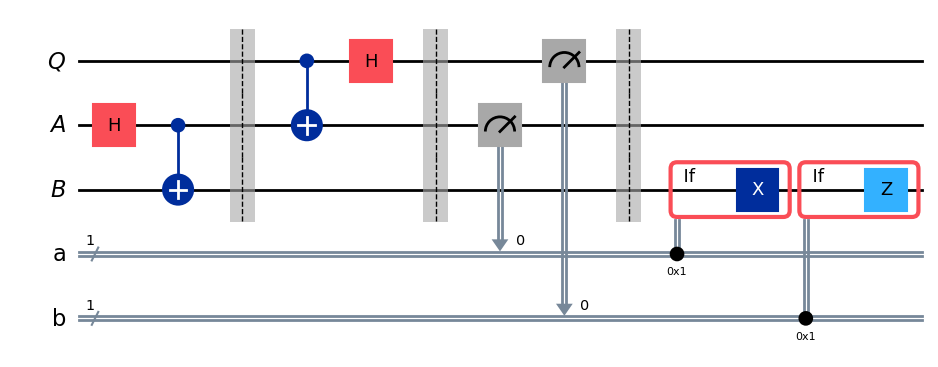

In [20]:
protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)

protocol.barrier()

# Alice's operations
protocol.cx(qubit,ebit0)
protocol.h(qubit)

protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0,a)
protocol.measure(qubit,b)

protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

protocol.draw(output='mpl')

* The circuit first initializes $(\mathsf{A},\mathsf{B})$ to be in a $\vert \phi^+\rangle$ state (which is not part of the protocol itself), followed by Alice's operations, then her measurements, and finally Bob's operations.

### Example

We will initialize Alice's qubit in a random state $\vert\psi\rangle$. This state will be created using an `Initialize` gate on $|q_0\rangle$.

<IPython.core.display.Latex object>

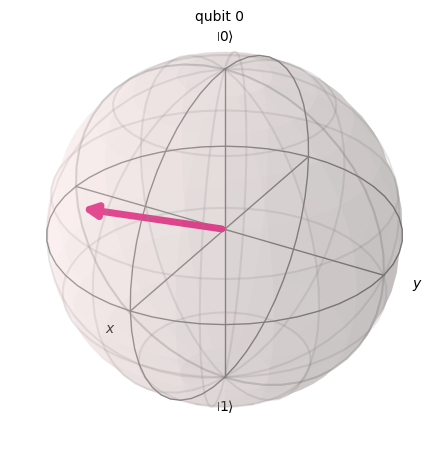

In [21]:
from qiskit.quantum_info import random_statevector
from qiskit.circuit.library import Initialize
from qiskit.visualization import array_to_latex, plot_bloch_multivector

# Create random 1-qubit state
psi = random_statevector(2)

# Display it nicely
display(array_to_latex(psi, prefix="|\\psi\\rangle ="))
plot_bloch_multivector(psi)

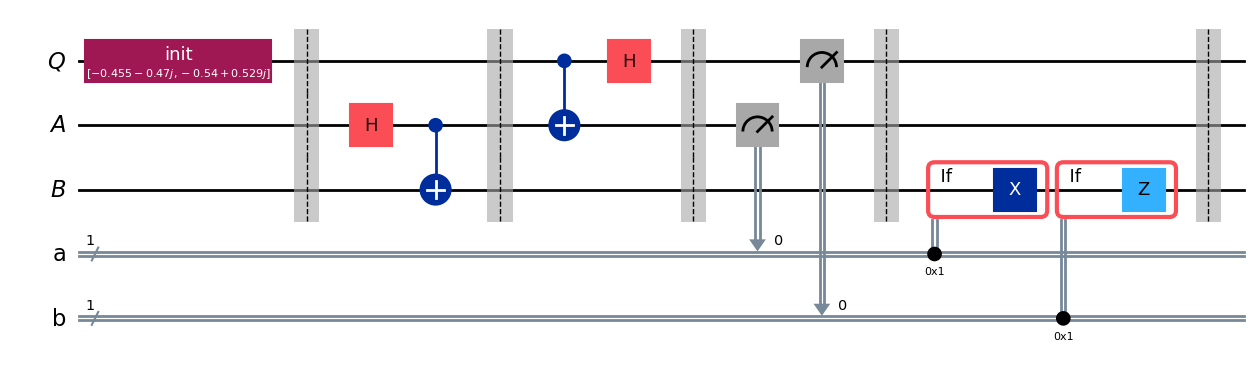

In [22]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol, along with a new "auxiliary" qubit R.
test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Initialize qubit with  Random Value
init_gate = Initialize(psi)
init_gate.label = "init"
test.append(init_gate, [0])
test.barrier()

# Append the protocol the circuit. The 'qubits' argument tells Qiskit that
# the protocol should operate on the qubits numbered 1, 2, and 3 (skipping
# qubit 0, which is R).
test = test.compose(protocol, qubits=[0, 1, 2])
test.barrier()



test.draw(output='mpl')

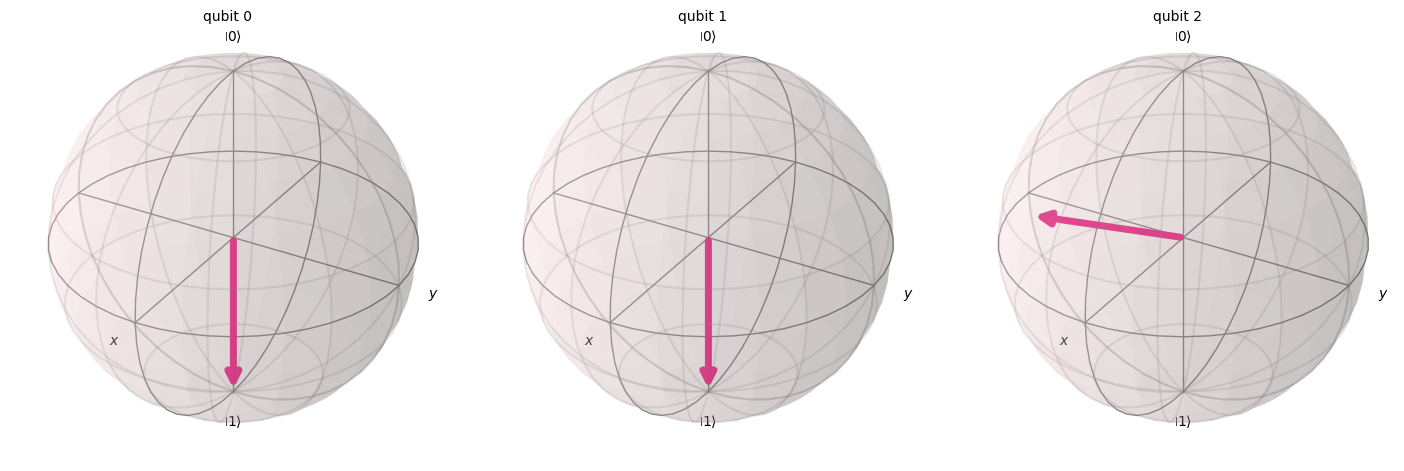

In [23]:
from qiskit_aer import AerSimulator
test.save_statevector()
out_vector = AerSimulator().run(test).result().get_statevector()
plot_bloch_multivector(out_vector)

### Recall the Original Vector

<IPython.core.display.Latex object>

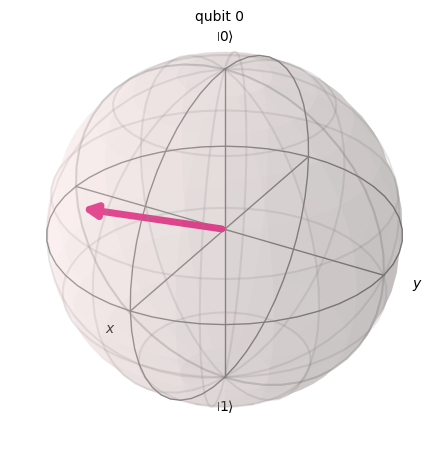

In [24]:
display(array_to_latex(psi, prefix="|\\psi\\rangle ="))
plot_bloch_multivector(psi)

### Problem:

To test that the protocol works correctly, let's check that it correctly teleports half of an entangled pair.
We can do this by creating a new circuit including a qubit $\mathsf{R}$, composing it with our protocol, and then adding gates and measurements to perform the test.

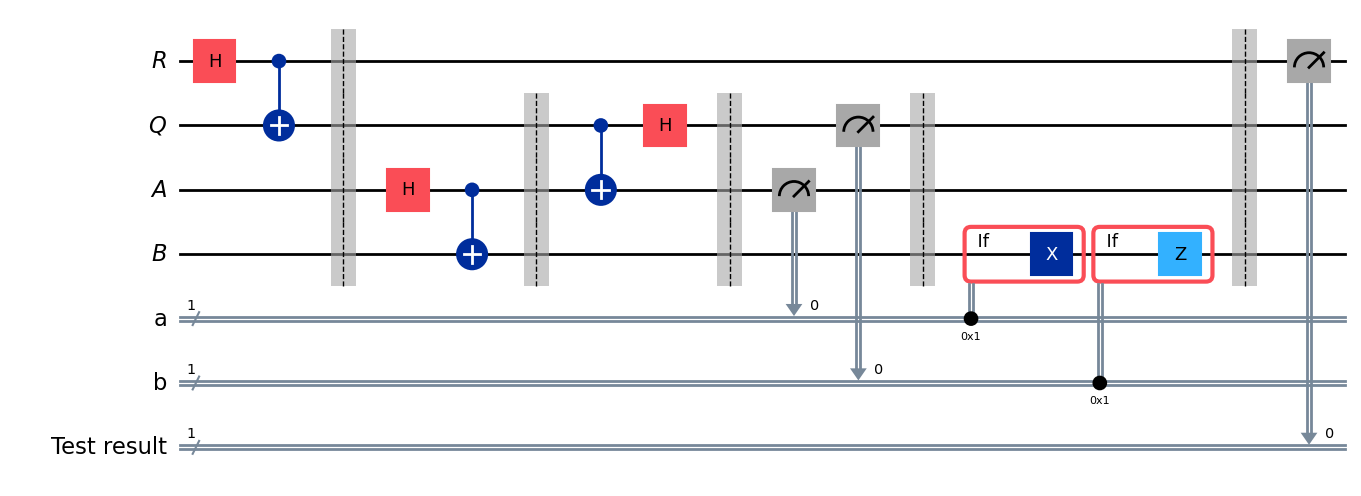

In [25]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol, along with a new "auxiliary" qubit R.
aux = QuantumRegister(1, "R")
test = QuantumCircuit(aux, qubit, ebit0, ebit1, a, b)

# Entangle Q with R
test.h(aux)
test.cx(aux,qubit)
test.barrier()

# Append the protocol the circuit. The 'qubits' argument tells Qiskit that
# the protocol should operate on the qubits numbered 1, 2, and 3 (skipping
# qubit 0, which is R).
test.compose(protocol, qubits=[1, 2, 3], inplace=True)
test.barrier()

# After the protocol runs, check that (B,R) is in a phi+ state. We can add
# a new classical bit to the circuit to do this.



result = ClassicalRegister(1, "Test result")
test.add_register(result)
test.measure(aux, result)

test.draw(output='mpl')

Finally let's run the Aer simulator on this circuit and plot a histogram of the outputs.
We'll see the statistics for all three classical bits:
the bottom/leftmost bit should always be $0$, indicating that the qubit $\mathsf{Q}$ was successfully teleported into $\mathsf{B}$, while the other two bits should be roughly uniform.

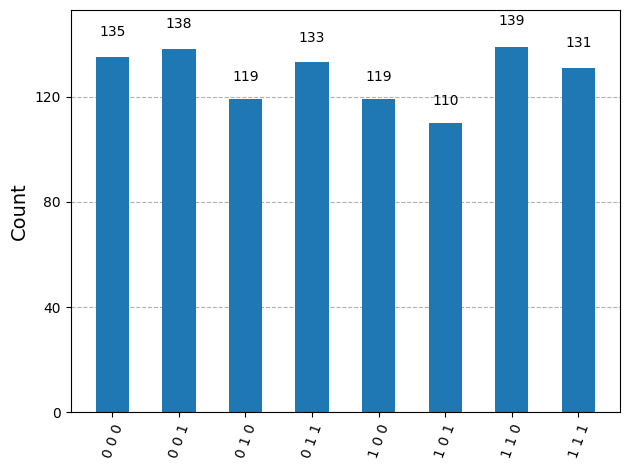

In [26]:
from qiskit.visualization import plot_histogram

counts = AerSimulator().run(test).result().get_counts()
plot_histogram(counts)

We can also filter the counts to focus just on the test result qubit if we wish, like this:

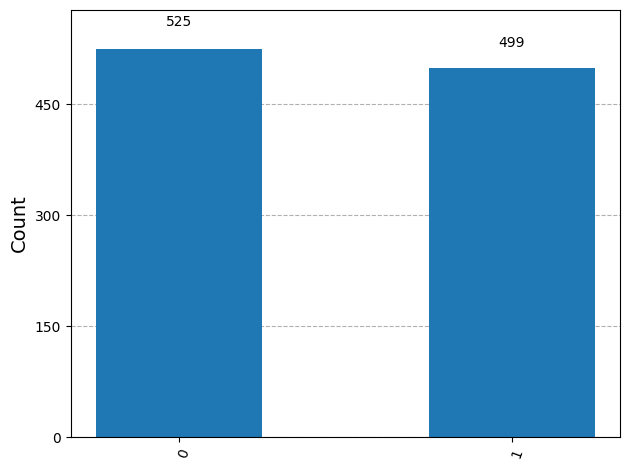

In [27]:
filtered_counts = {"0": 0, "1": 0}

for result, frequency in counts.items():
    filtered_counts[result[0]] += frequency

plot_histogram(filtered_counts)